# PoC: See and Talk Like A Graph — VLM on graph reasoning

**Goal ("fail early"):** before running the full experiment (12 tasks × 350 graphs × 3 settings), sanity-check the model service on a handful of real graphs. Look at the answers with our own eyes.

For each example we run **all 3 settings**:
1. `text_only`  — graph as adjacency text
2. `image_only` — rendered picture of the graph
3. `image_and_text` — both together

and compare the model's answer to the gold answer.

> **Switching to the real model:** this notebook defaults to the dependency-free `stub` so it runs on a laptop. On the GPU cluster, change `MODEL_NAME` below to `"qwen2.5-vl"` (or `"qwen-3b"`) and re-run — nothing else changes.

In [1]:
# Run from the repo root so imports resolve. If launched elsewhere, adjust.
import sys, os
from pathlib import Path

# Make the repo root importable regardless of where Jupyter was started.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "datasets").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
print("repo root:", REPO_ROOT)

repo root: /Users/yovel.hatan/see-and-talk-like-a-graph


In [2]:
# ==== CONFIG ====
# On the cluster: set MODEL_NAME = "qwen2.5-vl"  (or "qwen-3b")
MODEL_NAME = "stub"
IMAGE_TYPE = "spring"   # one of: spring | kamada_kawai | circular | planar
TASK = "cycle_check"    # which dataset file to load examples from
DATA_DIR = REPO_ROOT / "data"

In [3]:
from datasets.graph_qa_dataset import load_graphqa_dataset
from models import get_model

dataset = load_graphqa_dataset(DATA_DIR / f"{TASK}_adjacency_test.jsonl")
print(f"Loaded {len(dataset)} samples for task '{TASK}'.")

# The Qwen wrapper needs image_root to resolve relative image paths in the data.
model_kwargs = {} if MODEL_NAME == "stub" else {"image_root": str(DATA_DIR)}
model = get_model(MODEL_NAME, **model_kwargs)
print("model:", model.name)

Loaded 350 samples for task 'cycle_check'.
model: stub


## Pick an easy and a hard example

We sort by number of nodes and grab a small graph (should be easy — structure is obvious) and a large one (likely hard — a tangle from text, maybe clearer as an image).

In [4]:
by_size = sorted(dataset.samples, key=lambda s: s.metadata.get("nnodes", 0))
easy = by_size[0]
hard = by_size[-1]
chosen = {"EASY (small)": easy, "HARD (large)": hard}

for label, s in chosen.items():
    print(f"{label}: {s.sample_id} | nnodes={s.metadata.get('nnodes')} "
          f"nedges={s.metadata.get('nedges')} | gold={s.answer!r}")

EASY (small): cycle_check/adjacency/test/2 | nnodes=5 nedges=1 | gold='No, there is no cycle.'
HARD (large): cycle_check/adjacency/test/149 | nnodes=19 nedges=75 | gold='Yes, there is a cycle.'


## Helper: run one sample across all 3 settings

We build the same input dict the experiment loop builds, toggling `text`/`image` per setting.

In [5]:
SETTINGS = ["text_only", "image_only", "image_and_text"]

def make_input(sample, mode, image_type=IMAGE_TYPE):
    return {
        "sample_id": sample.sample_id,
        "question": sample.question,
        "text": sample.text_encoding if mode != "image_only" else None,
        "image": sample.images.get(image_type) if mode != "text_only" else None,
    }

def run_all_settings(sample):
    rows = []
    for mode in SETTINGS:
        out = model.generate_batch([make_input(sample, mode)])[0]
        rows.append({
            "setting": mode,
            "answer": out.get("answer"),
            "confidence": out.get("confidence"),
            "gold": sample.answer,
        })
    return rows

## Show the graph image (what the model sees in image settings)

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

def show_graph(sample, image_type=IMAGE_TYPE):
    img_path = DATA_DIR / sample.images[image_type]
    img = Image.open(img_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(img); plt.axis("off")
    plt.title(f"{sample.sample_id}  ({image_type})")
    plt.show()
    print("TEXT ENCODING:\n", sample.text_encoding)
    print("QUESTION:", sample.question)
    print("GOLD:", sample.answer)

## Example 1 — EASY (small graph)

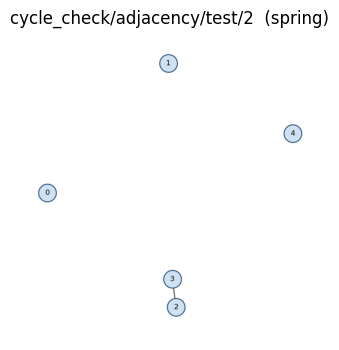

TEXT ENCODING:
 In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. G describes a graph among nodes 0, 1, 2, 3, and 4.
The edges in G are: (2, 3).

QUESTION: Q: Is there a cycle in this graph?
A: 
GOLD: No, there is no cycle.


,setting,answer,confidence,gold
0,text_only,Yes.,None,"No, there is no cycle."
1,image_only,Yes.,None,"No, there is no cycle."
2,image_and_text,Yes.,None,"No, there is no cycle."


In [7]:
show_graph(easy)
import pandas as pd
pd.DataFrame(run_all_settings(easy))

## Example 2 — HARD (large graph)

This is where we hope to see the interesting effect: text-only may struggle, image or image+text may help.

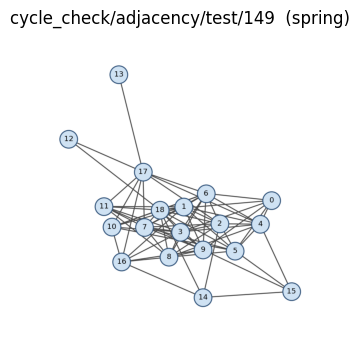

TEXT ENCODING:
 In an undirected graph, (i,j) means that node i and node j are connected with an undirected edge. G describes a graph among nodes 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, and 18.
The edges in G are: (0, 3) (0, 4) (0, 5) (0, 6) (0, 9) (0, 18) (1, 2) (1, 4) (1, 5) (1, 6) (1, 7) (1, 9) (1, 10) (1, 11) (1, 16) (1, 18) (2, 3) (2, 4) (2, 5) (2, 6) (2, 7) (2, 8) (2, 14) (2, 17) (2, 18) (3, 4) (3, 6) (3, 7) (3, 8) (3, 9) (3, 10) (3, 11) (3, 16) (3, 18) (4, 5) (4, 6) (4, 8) (4, 15) (4, 17) (5, 7) (5, 8) (5, 10) (5, 15) (5, 18) (6, 7) (6, 8) (6, 9) (6, 10) (6, 17) (6, 18) (7, 8) (7, 9) (7, 11) (7, 17) (7, 18) (8, 9) (8, 11) (8, 16) (8, 18) (9, 11) (9, 15) (9, 16) (9, 18) (10, 16) (10, 17) (10, 18) (11, 17) (11, 18) (12, 17) (12, 18) (13, 17) (14, 15) (14, 16) (14, 18) (16, 17).

QUESTION: Q: Is there a cycle in this graph?
A: 
GOLD: Yes, there is a cycle.


,setting,answer,confidence,gold
0,text_only,Yes.,None,"Yes, there is a cycle."
1,image_only,Yes.,None,"Yes, there is a cycle."
2,image_and_text,Yes.,None,"Yes, there is a cycle."


In [8]:
show_graph(hard)
pd.DataFrame(run_all_settings(hard))

## Hunt for the money case: text-only WRONG, image+text RIGHT

Scan a handful of samples and flag any where adding the image flips a wrong answer to a correct one — this is direct evidence for the project's hypothesis. (Uses a loose string match; the real experiment/analysis will use proper answer parsing.)

In [9]:
def is_correct(answer, gold):
    if answer is None:
        return False
    a, g = answer.strip().lower(), gold.strip().lower()
    # crude yes/no match for the PoC only
    if g.startswith("yes"):
        return a.startswith("yes")
    if g.startswith("no"):
        return a.startswith("no")
    return g in a

money_cases = []
for s in by_size[:20]:   # small sweep for the PoC
    rows = {r["setting"]: r for r in run_all_settings(s)}
    text_ok = is_correct(rows["text_only"]["answer"], s.answer)
    both_ok = is_correct(rows["image_and_text"]["answer"], s.answer)
    if (not text_ok) and both_ok:
        money_cases.append(s.sample_id)

print("Cases where text-only failed but image+text succeeded:")
print(money_cases if money_cases else "(none in this sweep — expected with the stub; look again with real Qwen)")

Cases where text-only failed but image+text succeeded:
(none in this sweep — expected with the stub; look again with real Qwen)


## Takeaways

_Fill in after running with the real model on the cluster:_

- Does the model read small graphs correctly from the image alone?
- At what graph size does image-only start to fail (unreadable tangle)?
- Any clear case where the image rescued a wrong text-only answer?
- Which image layout (spring / circular / planar) seems easiest for the model?